# 02 — Visium Foundation Model Benchmark

This notebook benchmarks pathology foundation models on a 10x Genomics Visium breast cancer sample.

The workflow is:

1. Load Visium expression data and the matched H&E image.
2. Compute transcriptomic Leiden clusters as the reference.
3. Extract identical H&E patches around Visium spots.
4. Generate morphology embeddings with PLIP, UNI, CONCH, and Virchow.
5. Apply PCA, spatial graph smoothing, and KMeans clustering.
6. Evaluate morphology-derived clusters against transcriptomic clusters using ARI and NMI.

Final benchmark settings:

- PATCH_SIZE = 112
- N_CLUSTERS = 10
- SMOOTH_K = 20
- TRANSCRIPTOMIC_RESOLUTION = 0.6
- EMBEDDING_PCA_DIM = 50


In [ ]:
import os
from pathlib import Path

if not Path("/content/SpatialBio").exists():
    !git clone https://github.com/Mmasoud1/SpatialBio.git /content/SpatialBio

%cd /content/SpatialBio

!pip install -q -r requirements.txt
!pip install -q timm transformers huggingface_hub
!pip install -q git+https://github.com/Mahmoodlab/CONCH.git


Cloning into '/content/SpatialBio'...
remote: Enumerating objects: 60, done.
remote: Counting objects: 100% (37/37), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 60 (delta 14), reused 29 (delta 7), pack-reused 23 (from 1)
Receiving objects: 100% (60/60), 96.59 MiB | 15.19 MiB/s, done.
Resolving deltas: 100% (16/16), done.
/content/SpatialBio
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 9.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 9.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 89.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.9/193.9 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 17.2 MB/s eta

In [ ]:
import os
import gc
import time
import zipfile
import json
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn.functional as F

import scanpy as sc
import squidpy as sq

from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)


Device: cuda


## 1. Configuration

These settings reproduce the strongest UNI benchmark from the parameter sweep and are kept fixed for all foundation models.


In [ ]:
LIBRARY_ID = None

RAW_DIR = Path("/content/SpatialBio/data/raw")
ZIP_PATH = RAW_DIR / "breast_visium.zip"
VISIUM_PATH = RAW_DIR / "breast"

PATCH_SIZE = 112
N_CLUSTERS = 10
SMOOTH_K = 20
MAX_SPOTS = None
RANDOM_STATE = 42

N_HVG = 2000
TRANSCRIPTOMIC_RESOLUTION = 0.6
EMBEDDING_PCA_DIM = 50

MODELS_TO_RUN = [
    "PLIP",
    "UNI",
    "CONCH",
    "VIRCHOW",
]

MODEL_BATCH_SIZE = {
    "PLIP": 32,
    "UNI": 16,
    "CONCH": 32,
    "VIRCHOW": 4,
}


In [ ]:
if not VISIUM_PATH.exists():
    if ZIP_PATH.exists():
        with zipfile.ZipFile(ZIP_PATH, "r") as z:
            z.extractall(RAW_DIR)
    else:
        raise FileNotFoundError(
            f"Could not find {VISIUM_PATH} or {ZIP_PATH}. "
            "Make sure data/raw/breast_visium.zip exists in the repo."
        )

print("Visium path:", VISIUM_PATH)


Visium path: /content/SpatialBio/data/raw/breast


## 2. Hugging Face authentication

Needa Hugging Face token with access granted  to UNI, CONCH, and Virchow.


In [ ]:
from huggingface_hub import login

login()


## 3. Load Visium data and H&E image

In [ ]:
from pathlib import Path
import json

VISIUM_PATH = Path(VISIUM_PATH)

# Read Visium spatial positions
def read_spatial_positions(spatial_dir: Path) -> pd.DataFrame:
    candidates = [
        spatial_dir / "tissue_positions.csv",
        spatial_dir / "tissue_positions_list.csv",
    ]

    pos_file = next((p for p in candidates if p.exists()), None)
    if pos_file is None:
        raise FileNotFoundError(
            f"Could not find tissue_positions.csv or tissue_positions_list.csv in {spatial_dir}"
        )

    # New format has a header. Old does not.
    first_line = pos_file.read_text().splitlines()[0]
    has_header = first_line.lower().startswith("barcode")

    cols = [
        "barcode",
        "in_tissue",
        "array_row",
        "array_col",
        "pxl_row_in_fullres",
        "pxl_col_in_fullres",
    ]

    if has_header:
        pos = pd.read_csv(pos_file)
    else:
        pos = pd.read_csv(pos_file, header=None, names=cols)

    # Standardize column names
    rename_map = {
        "pxl_row_in_fullres": "pxl_row_in_fullres",
        "pxl_col_in_fullres": "pxl_col_in_fullres",
    }
    pos = pos.rename(columns=rename_map)
    pos = pos.set_index("barcode")
    return pos

# Visium reader for h5 or mtx-based 10x folders
def read_visium_any(visium_path: Path, library_id="breast"):
    spatial_dir = visium_path / "spatial"
    matrix_h5 = visium_path / "filtered_feature_bc_matrix.h5"
    matrix_dir = visium_path / "filtered_feature_bc_matrix"

    if matrix_h5.exists():
        adata = sc.read_10x_h5(matrix_h5)
    elif matrix_dir.exists():
        adata = sc.read_10x_mtx(
            matrix_dir,
            var_names="gene_symbols",
            make_unique=True,
        )
    else:
        raise FileNotFoundError(
            f"Could not find filtered_feature_bc_matrix.h5 or filtered_feature_bc_matrix/ in {visium_path}"
        )

    adata.var_names_make_unique()

    # Load spatial positions and align to adata barcodes
    pos = read_spatial_positions(spatial_dir)
    common = adata.obs_names.intersection(pos.index)
    if len(common) == 0:
        raise ValueError("No matching barcodes between expression matrix and tissue positions.")

    adata = adata[common].copy()
    pos = pos.loc[adata.obs_names]

    adata.obs["in_tissue"] = pos["in_tissue"].astype(int).values
    adata.obs["array_row"] = pos["array_row"].astype(int).values
    adata.obs["array_col"] = pos["array_col"].astype(int).values

    adata.obsm["spatial"] = pos[["pxl_col_in_fullres", "pxl_row_in_fullres"]].to_numpy(dtype=float)

    # Load scalefactors
    scalefactors_file = spatial_dir / "scalefactors_json.json"
    if scalefactors_file.exists():
        with open(scalefactors_file) as f:
            scalefactors = json.load(f)
    else:
        scalefactors = {}

    # Load images
    images = {}
    hires_path = spatial_dir / "tissue_hires_image.png"
    lowres_path = spatial_dir / "tissue_lowres_image.png"

    if hires_path.exists():
        images["hires"] = plt.imread(hires_path)
    if lowres_path.exists():
        images["lowres"] = plt.imread(lowres_path)

    adata.uns["spatial"] = {
        library_id: {
            "images": images,
            "scalefactors": scalefactors,
            "metadata": {
                "source_image_path": str(spatial_dir),
            },
        }
    }

    return adata

library_id = LIBRARY_ID or "breast"
adata = read_visium_any(VISIUM_PATH, library_id=library_id)

print(adata)
print("Spatial keys:", list(adata.uns.get("spatial", {}).keys()))

spatial_info = adata.uns["spatial"][library_id]

# Prefer high-res image when available
if "hires" in spatial_info["images"]:
    img = spatial_info["images"]["hires"]
    scale_factor = spatial_info["scalefactors"].get("tissue_hires_scalef", 1.0)
    image_name = "hires"
elif "lowres" in spatial_info["images"]:
    img = spatial_info["images"]["lowres"]
    scale_factor = spatial_info["scalefactors"].get("tissue_lowres_scalef", 1.0)
    image_name = "lowres"
else:
    raise ValueError("No hires or lowres image found in spatial folder.")

# Convert image to uint8 RGB if needed
if img.max() <= 1.0:
    img_uint8 = (img * 255).astype(np.uint8)
else:
    img_uint8 = img.astype(np.uint8)

# Remove alpha channel if present
if img_uint8.ndim == 3 and img_uint8.shape[2] == 4:
    img_uint8 = img_uint8[:, :, :3]

img_pil = Image.fromarray(img_uint8).convert("RGB")
print("Using image:", image_name, "shape:", img_uint8.shape, "scale factor:", scale_factor)

# Convert full resolution tissue coordinates to current image coordinates
coords_fullres = adata.obsm["spatial"]
coords_img = coords_fullres * scale_factor


if MAX_SPOTS is not None and MAX_SPOTS < adata.n_obs:
    rng = np.random.default_rng(RANDOM_STATE)
    idx = np.sort(rng.choice(adata.n_obs, size=MAX_SPOTS, replace=False))
    adata_sub = adata[idx].copy()
    coords_sub = coords_img[idx]
else:
    adata_sub = adata.copy()
    coords_sub = coords_img.copy()

print("Number of spots used:", adata_sub.n_obs)


AnnData object with n_obs × n_vars = 4898 × 36601
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types'
    uns: 'spatial'
    obsm: 'spatial'
Spatial keys: ['breast']
Using image: hires shape: (1335, 2000, 3) scale factor: 0.048109304
Number of spots used: 4898


## 4. Transcriptomic reference

Transcriptomic Leiden clusters are used as the biological reference for ARI/NMI evaluation.


In [ ]:
# Transcriptomic preprocessing and clustering
adata_t = adata_sub.copy()

sc.pp.filter_genes(adata_t, min_cells=3)
sc.pp.normalize_total(adata_t, target_sum=1e4)
sc.pp.log1p(adata_t)
sc.pp.highly_variable_genes(adata_t, flavor="seurat", n_top_genes=min(N_HVG, adata_t.n_vars))
adata_t = adata_t[:, adata_t.var["highly_variable"]].copy()

sc.pp.scale(adata_t, max_value=10)
sc.tl.pca(adata_t, svd_solver="arpack")
sc.pp.neighbors(adata_t, n_neighbors=12, n_pcs=min(30, adata_t.obsm["X_pca"].shape[1]))
sc.tl.leiden(adata_t, resolution=TRANSCRIPTOMIC_RESOLUTION, key_added="transcriptomic_leiden")

adata_sub.obs["transcriptomic_leiden"] = adata_t.obs["transcriptomic_leiden"].astype(str).values
print(adata_sub.obs["transcriptomic_leiden"].value_counts().sort_index())

transcriptomic_leiden
0     784
1     783
10     62
2     772
3     760
4     543
5     402
6     333
7     231
8     122
9     106
Name: count, dtype: int64


## 5. H&E patch extraction

Each Visium spot is represented by one RGB patch centered on the spot coordinate.


Patches: 4898
Patch size: (112, 112)


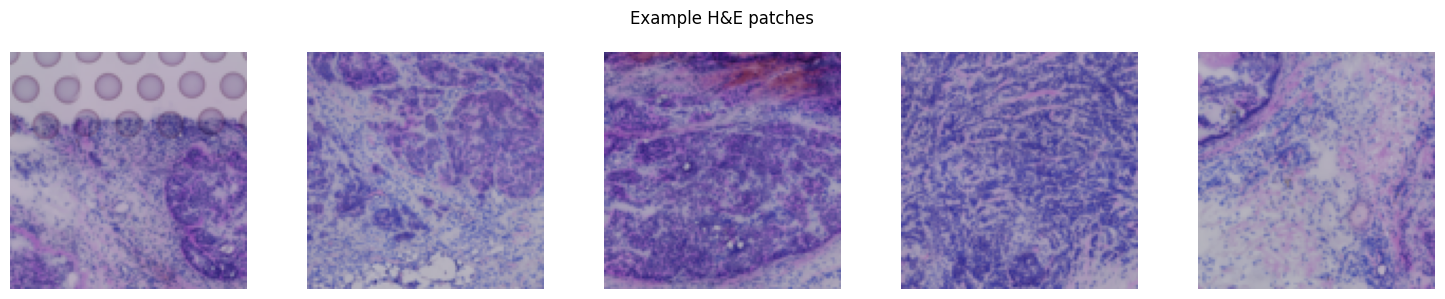

In [ ]:
def extract_patch(img_pil, x, y, patch_size=112):
    half = patch_size // 2
    x, y = int(round(x)), int(round(y))
    left, upper = x - half, y - half
    right, lower = x + half, y + half

    patch = Image.new("RGB", (patch_size, patch_size), (255, 255, 255))
    crop = img_pil.crop((max(left, 0), max(upper, 0), min(right, img_pil.width), min(lower, img_pil.height)))

    paste_x = max(0, -left)
    paste_y = max(0, -upper)
    patch.paste(crop, (paste_x, paste_y))

    return patch


patches = [extract_patch(img_pil, x, y, PATCH_SIZE) for x, y in coords_sub]

print(f"Patches: {len(patches)}")
print("Patch size:", patches[0].size)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax, patch in zip(axes, patches[:5]):
    ax.imshow(patch)
    ax.axis("off")
plt.suptitle("Example H&E patches")
plt.tight_layout()
plt.show()


## 6. Foundation model loaders

In [ ]:
from transformers import CLIPModel, CLIPProcessor
import timm
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform

# Convert model outputs into a feature tensor.
def _safe_feature_tensor(output):

    if isinstance(output, torch.Tensor):
        return output

    if hasattr(output, "image_embeds") and output.image_embeds is not None:
        return output.image_embeds

    if hasattr(output, "pooler_output") and output.pooler_output is not None:
        return output.pooler_output

    if hasattr(output, "last_hidden_state") and output.last_hidden_state is not None:
        return output.last_hidden_state[:, 0]

    if isinstance(output, (tuple, list)):
        for item in output:
            if isinstance(item, torch.Tensor):
                return item

    raise TypeError(f"Could not extract tensor features from output type: {type(output)}")

# PLIP image encoder.
def load_plip(device=DEVICE):
    model_name = "vinid/plip"
    processor = CLIPProcessor.from_pretrained(model_name)
    model = CLIPModel.from_pretrained(model_name).to(device).eval()

    def embed_patches(patches):
        inputs = processor(images=patches, return_tensors="pt", padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.inference_mode():
            try:
                feats = model.get_image_features(**inputs)
                feats = _safe_feature_tensor(feats)
            except Exception:
                # Robust fallback through the vision tower
                vision_out = model.vision_model(pixel_values=inputs["pixel_values"])
                feats = _safe_feature_tensor(vision_out)
                if hasattr(model, "visual_projection") and model.visual_projection is not None:
                    feats = model.visual_projection(feats)

            feats = F.normalize(feats.float(), dim=1)

        return feats.detach().cpu().numpy()

    return embed_patches

# UNI ViT-L/16 pathology image encoder via timm.
def load_uni(device=DEVICE):
    model = timm.create_model(
        pretrained=True,
        init_values=1e-5,
        dynamic_img_size=True,
    ).to(device).eval()

    transform = create_transform(**resolve_data_config(model.pretrained_cfg, model=model))

    def embed_patches(patches):
        x = torch.stack([transform(p) for p in patches]).to(device)

        with torch.inference_mode():
            feats = model(x)
            feats = F.normalize(feats.float(), dim=1)

        return feats.detach().cpu().numpy()

    return embed_patches

# CONCH image encoder
def load_conch(device=DEVICE):
    from conch.open_clip_custom import create_model_from_pretrained

    model, preprocess = create_model_from_pretrained(
        "conch_ViT-B-16",
    )
    model = model.to(device).eval()

    def embed_patches(patches):
        x = torch.stack([preprocess(p) for p in patches]).to(device)

        with torch.inference_mode():
            # Features before projection head are suitable for linear probing / WSI workflows.
            feats = model.encode_image(
                x,
                proj_contrast=False,
                normalize=False,
            )
            feats = F.normalize(feats.float(), dim=1)

        return feats.detach().cpu().numpy()

    return embed_patches

# Virchow ViT-H/14 encoder.
def load_virchow(device=DEVICE):
    from timm.layers import SwiGLUPacked

    model = timm.create_model(
        "hf-hub:paige-ai/Virchow",
        pretrained=True,
        mlp_layer=SwiGLUPacked,
        act_layer=torch.nn.SiLU,
    ).to(device).eval()

    transform = create_transform(**resolve_data_config(model.pretrained_cfg, model=model))

    def embed_patches(patches):
        x = torch.stack([transform(p) for p in patches]).to(device)

        with torch.inference_mode():
            use_amp = device == "cuda"
            with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=use_amp):
                out = model(x)

            if out.ndim == 3:
                class_token = out[:, 0]
                patch_tokens = out[:, 1:]
                feats = torch.cat([class_token, patch_tokens.mean(dim=1)], dim=-1)
            else:
                feats = out

            feats = F.normalize(feats.float(), dim=1)

        return feats.detach().cpu().numpy()

    return embed_patches


MODEL_LOADERS = {
    "PLIP": load_plip,
    "UNI": load_uni,
    "CONCH": load_conch,
    "VIRCHOW": load_virchow,
}


## 7. Shared analysis functions

In [ ]:
def extract_embeddings(patches, embed_fn, batch_size=32, desc="Embedding patches"):
    all_feats = []

    for start in tqdm(range(0, len(patches), batch_size), desc=desc):
        batch = patches[start:start + batch_size]
        feats = embed_fn(batch)
        all_feats.append(feats)

    return np.vstack(all_feats)


def reduce_embeddings(X, n_components=50):
    Xs = StandardScaler().fit_transform(X)
    n_components = min(n_components, Xs.shape[0] - 1, Xs.shape[1])

    if n_components < 2:
        return Xs

    return PCA(n_components=n_components, random_state=RANDOM_STATE).fit_transform(Xs)


def smooth_embeddings_spatial(X, coords, k=20):
    k = min(k, len(coords))
    nn = NearestNeighbors(n_neighbors=k, metric="euclidean")
    nn.fit(coords)
    neigh_idx = nn.kneighbors(coords, return_distance=False)

    return np.vstack([X[idx].mean(axis=0) for idx in neigh_idx])


def cluster_embeddings(X, n_clusters=10):
    return KMeans(
        n_clusters=n_clusters,
        random_state=RANDOM_STATE,
        n_init="auto",
    ).fit_predict(X).astype(str)


def evaluate_clusters(ref_labels, pred_labels):
    return {
        "ARI": adjusted_rand_score(ref_labels, pred_labels),
        "NMI": normalized_mutual_info_score(ref_labels, pred_labels),
    }


## 8. Run benchmark

In [ ]:
results = []
embeddings_by_model = {}
clusters_by_model = {}

ref = adata_sub.obs["transcriptomic_leiden"].astype(str).values

for model_name in MODELS_TO_RUN:
    print("\n" + "=" * 80)
    print(f"Running model: {model_name}")
    print("=" * 80)

    start_time = time.time()

    try:
        embed_fn = MODEL_LOADERS[model_name]()
        batch_size = MODEL_BATCH_SIZE.get(model_name, 16)

        X = extract_embeddings(
            patches,
            embed_fn,
            batch_size=batch_size,
            desc=f"{model_name} embeddings",
        )

        X_red = reduce_embeddings(X, EMBEDDING_PCA_DIM)
        X_smooth = smooth_embeddings_spatial(X_red, coords_sub, SMOOTH_K)

        raw_clusters = cluster_embeddings(X_red, N_CLUSTERS)
        smooth_clusters = cluster_embeddings(X_smooth, N_CLUSTERS)

        raw_metrics = evaluate_clusters(ref, raw_clusters)
        smooth_metrics = evaluate_clusters(ref, smooth_clusters)

        runtime_sec = time.time() - start_time

        embeddings_by_model[model_name] = {"raw": X_red, "smooth": X_smooth}
        clusters_by_model[model_name] = {"raw": raw_clusters, "smooth": smooth_clusters}

        adata_sub.obs[f"{model_name}_raw_clusters"] = raw_clusters
        adata_sub.obs[f"{model_name}_smooth_clusters"] = smooth_clusters

        results.append({
            "model": model_name,
            "status": "success",
            "patch_size": PATCH_SIZE,
            "n_clusters": N_CLUSTERS,
            "smooth_k": SMOOTH_K,
            "embedding_dim": X.shape[1],
            "runtime_sec": runtime_sec,
            "raw_ARI": raw_metrics["ARI"],
            "raw_NMI": raw_metrics["NMI"],
            f"smoothed_k{SMOOTH_K}_ARI": smooth_metrics["ARI"],
            f"smoothed_k{SMOOTH_K}_NMI": smooth_metrics["NMI"],
        })

        print(f"{model_name} raw:      ARI={raw_metrics['ARI']:.4f}, NMI={raw_metrics['NMI']:.4f}")
        print(f"{model_name} smoothed: ARI={smooth_metrics['ARI']:.4f}, NMI={smooth_metrics['NMI']:.4f}")
        print(f"Embedding shape: {X.shape}")
        print(f"Runtime: {runtime_sec:.1f} sec")

    except Exception as e:
        runtime_sec = time.time() - start_time

        results.append({
            "model": model_name,
            "status": "failed",
            "patch_size": PATCH_SIZE,
            "n_clusters": N_CLUSTERS,
            "smooth_k": SMOOTH_K,
            "embedding_dim": np.nan,
            "runtime_sec": runtime_sec,
            "raw_ARI": np.nan,
            "raw_NMI": np.nan,
            f"smoothed_k{SMOOTH_K}_ARI": np.nan,
            f"smoothed_k{SMOOTH_K}_NMI": np.nan,
            "error": repr(e),
        })

        print(f"FAILED: {model_name}")
        print(repr(e))

    finally:
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

results_df = pd.DataFrame(results)
results_df



Running model: PLIP


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/4.46k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/568 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/716 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.52G [00:00<?, ?B/s]

VIRCHOW embeddings:   0%|          | 0/1225 [00:00<?, ?it/s]

VIRCHOW raw:      ARI=0.1552, NMI=0.2953
VIRCHOW smoothed: ARI=0.1873, NMI=0.3612
Embedding shape: (4898, 2560)
Runtime: 175.0 sec


,model,status,patch_size,n_clusters,smooth_k,embedding_dim,runtime_sec,raw_ARI,raw_NMI,smoothed_k20_ARI,smoothed_k20_NMI
0,PLIP,success,112,10,20,512,35.415100,0.216158,0.357220,0.263391,0.384386
1,UNI,success,112,10,20,1024,186.702792,0.260433,0.425760,0.310151,0.450343
2,CONCH,success,112,10,20,512,286.829264,0.185707,0.333990,0.229749,0.380769
3,VIRCHOW,success,112,10,20,2560,174.965061,0.155158,0.295288,0.187331,0.361214


## 9. Quantitative results

,model,status,embedding_dim,patch_size,n_clusters,smooth_k,raw_ARI,raw_NMI,smoothed_k20_ARI,smoothed_k20_NMI,runtime_sec
1,UNI,success,1024,112,10,20,0.260433,0.425760,0.310151,0.450343,186.702792
0,PLIP,success,512,112,10,20,0.216158,0.357220,0.263391,0.384386,35.415100
2,CONCH,success,512,112,10,20,0.185707,0.333990,0.229749,0.380769,286.829264
3,VIRCHOW,success,2560,112,10,20,0.155158,0.295288,0.187331,0.361214,174.965061


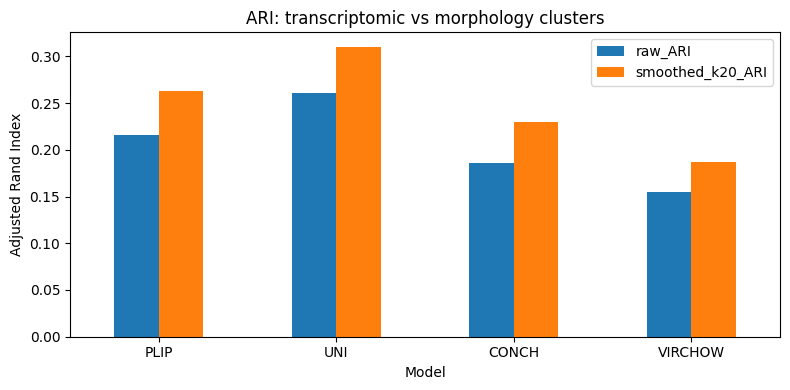

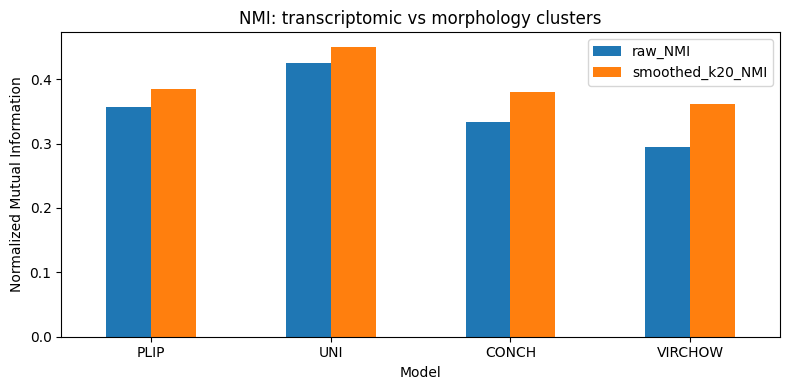

Best model by smoothed ARI: UNI
Smoothed ARI: 0.3102
Smoothed NMI: 0.4503


In [ ]:
ari_col = f"smoothed_k{SMOOTH_K}_ARI"
nmi_col = f"smoothed_k{SMOOTH_K}_NMI"

summary_cols = [
    "model",
    "status",
    "embedding_dim",
    "patch_size",
    "n_clusters",
    "smooth_k",
    "raw_ARI",
    "raw_NMI",
    ari_col,
    nmi_col,
    "runtime_sec",
]

summary_df = results_df[summary_cols].sort_values(
    ari_col,
    ascending=False,
    na_position="last",
)

display(summary_df)

plot_df = results_df[results_df["status"] == "success"].set_index("model")

if len(plot_df):
    ax = plot_df[["raw_ARI", ari_col]].plot(kind="bar", figsize=(8, 4))
    ax.set_title("ARI: transcriptomic vs morphology clusters")
    ax.set_ylabel("Adjusted Rand Index")
    ax.set_xlabel("Model")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

    ax = plot_df[["raw_NMI", nmi_col]].plot(kind="bar", figsize=(8, 4))
    ax.set_title("NMI: transcriptomic vs morphology clusters")
    ax.set_ylabel("Normalized Mutual Information")
    ax.set_xlabel("Model")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

    best_model = plot_df[ari_col].idxmax()
    print(f"Best model by smoothed ARI: {best_model}")
    print(f"Smoothed ARI: {plot_df.loc[best_model, ari_col]:.4f}")
    print(f"Smoothed NMI: {plot_df.loc[best_model, nmi_col]:.4f}")


## 10. Spatial visualization

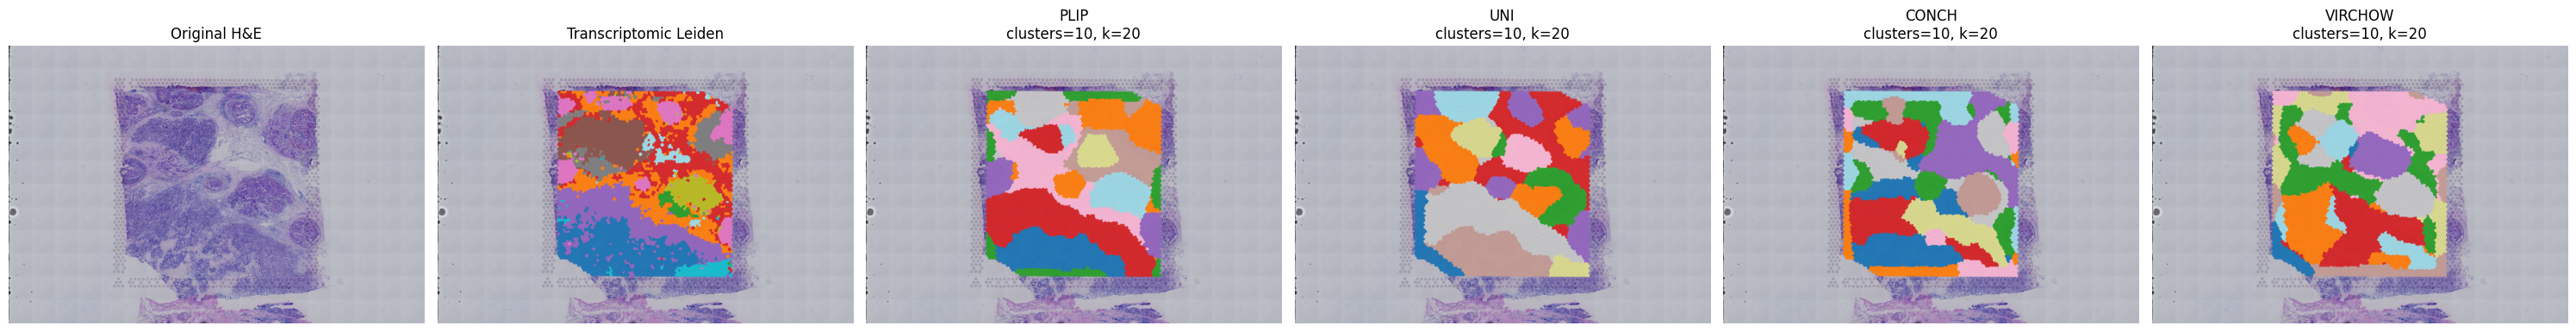

In [ ]:
successful_models = [m for m in MODELS_TO_RUN if f"{m}_smooth_clusters" in adata_sub.obs]

if successful_models:
    ncols = 2 + len(successful_models)
    fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 5))

    axes[0].imshow(img_uint8)
    axes[0].set_title("Original H&E")
    axes[0].axis("off")

    axes[1].imshow(img_uint8)
    tx = adata_sub.obs["transcriptomic_leiden"].astype("category").cat.codes.values
    axes[1].scatter(coords_sub[:, 0], coords_sub[:, 1], c=tx, s=4, cmap="tab20", alpha=0.85)
    axes[1].set_title("Transcriptomic Leiden")
    axes[1].axis("off")

    for ax, model_name in zip(axes[2:], successful_models):
        morph = adata_sub.obs[f"{model_name}_smooth_clusters"].astype("category").cat.codes.values
        ax.imshow(img_uint8)
        ax.scatter(coords_sub[:, 0], coords_sub[:, 1], c=morph, s=4, cmap="tab20", alpha=0.85)
        ax.set_title(f"{model_name}\nclusters={N_CLUSTERS}, k={SMOOTH_K}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No successful models to plot.")


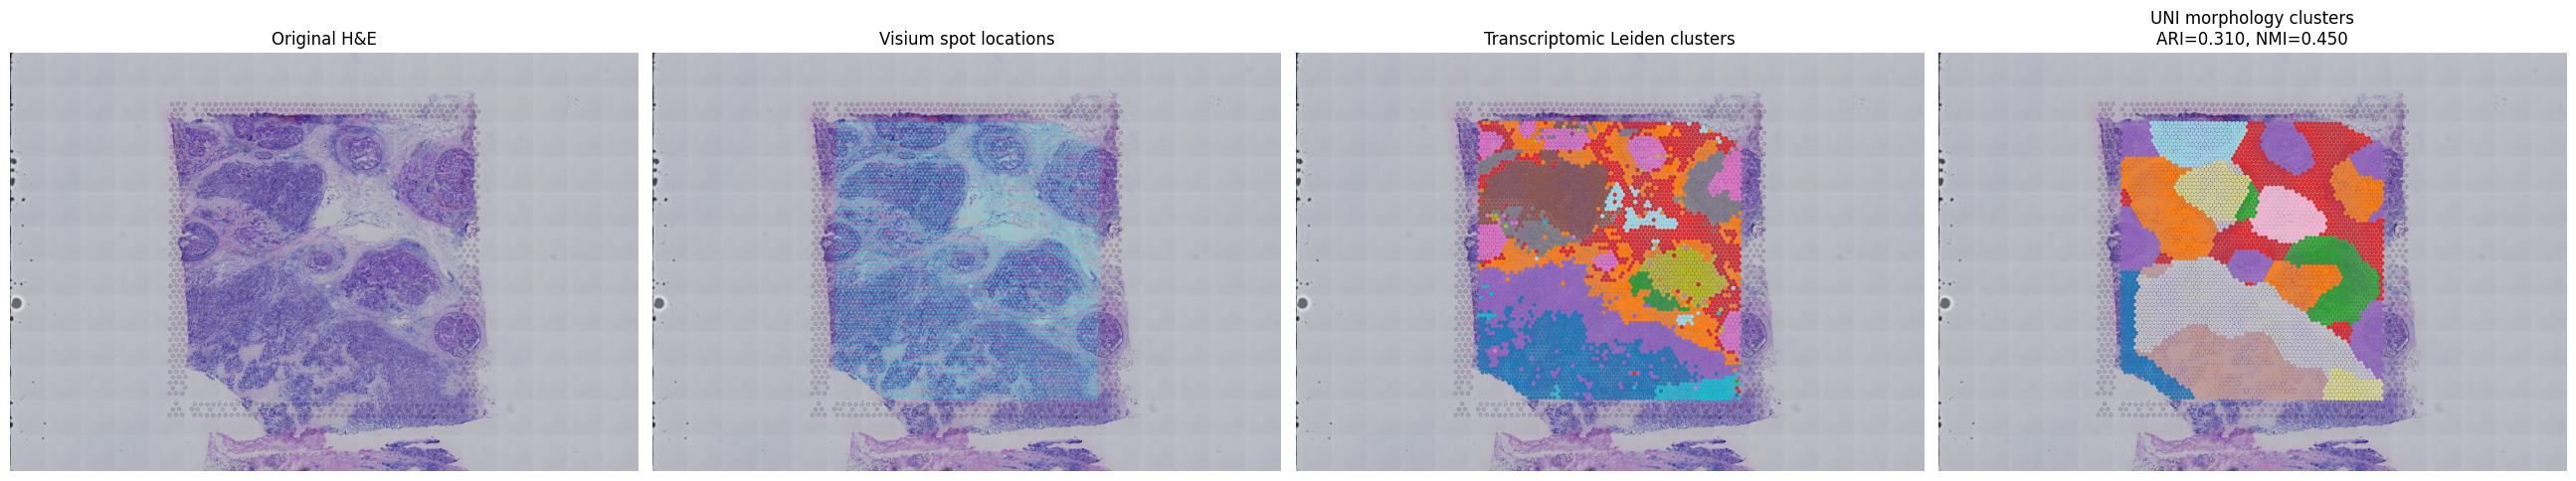

In [ ]:
best_model = None

if len(results_df[results_df["status"] == "success"]):
    best_model = results_df[results_df["status"] == "success"].sort_values(
        f"smoothed_k{SMOOTH_K}_ARI",
        ascending=False,
    ).iloc[0]["model"]

if best_model is not None:
    tx = adata_sub.obs["transcriptomic_leiden"].astype("category").cat.codes.values
    morph = adata_sub.obs[f"{best_model}_smooth_clusters"].astype("category").cat.codes.values

    best_row = results_df[results_df["model"] == best_model].iloc[0]
    best_ari = best_row[f"smoothed_k{SMOOTH_K}_ARI"]
    best_nmi = best_row[f"smoothed_k{SMOOTH_K}_NMI"]

    fig, axes = plt.subplots(1, 4, figsize=(26, 6))

    axes[0].imshow(img_uint8)
    axes[0].set_title("Original H&E")
    axes[0].axis("off")

    axes[1].imshow(img_uint8)
    axes[1].scatter(coords_sub[:, 0], coords_sub[:, 1], s=0.5, c="cyan", alpha=0.4)
    axes[1].set_title("Visium spot locations")
    axes[1].axis("off")

    axes[2].imshow(img_uint8)
    axes[2].scatter(coords_sub[:, 0], coords_sub[:, 1], c=tx, s=4, cmap="tab20", alpha=0.85)
    axes[2].set_title("Transcriptomic Leiden clusters")
    axes[2].axis("off")

    axes[3].imshow(img_uint8)
    axes[3].scatter(coords_sub[:, 0], coords_sub[:, 1], c=morph, s=4, cmap="tab20", alpha=0.85)
    axes[3].set_title(
        f"{best_model} morphology clusters\n"
        f"ARI={best_ari:.3f}, NMI={best_nmi:.3f}"
    )
    axes[3].axis("off")

    plt.tight_layout()
    plt.show()


## 11. Save outputs

In [ ]:
OUT_DIR = "/content/visium_foundation_model_comparison_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

if len(results_df):
    results_df.to_csv(
        os.path.join(OUT_DIR, "foundation_model_comparison_metrics.csv"),
        index=False,
    )

adata_sub.write(
    os.path.join(OUT_DIR, "visium_foundation_model_comparison.h5ad")
)

print("Saved outputs to:", OUT_DIR)


## Conclusion

This notebook benchmarks PLIP, UNI, CONCH, and Virchow on a Visium breast cancer H&E image using the same patch extraction, PCA reduction, spatial smoothing, clustering, and ARI/NMI evaluation pipeline.

Using `PATCH_SIZE=112`, `N_CLUSTERS=10`, and `SMOOTH_K=20`, UNI achieved the strongest morphology-transcriptomics agreement in this benchmark. The result suggests that pathology foundation-model embeddings can capture biologically meaningful tissue organization directly from routine H&E morphology.

This workflow is useful because it turns foundation model embeddings into measurable spatial biology outputs: tissue compartments, model rankings, and morphology-transcriptomics agreement scores. It also provides a clean baseline for future graph neural network and Xenium cell-level analyses.
